## Plot Monsoon climatological daily cumulative sum of AIR region precipitation 

In [1]:
# Importing packages

import xarray as xr
import pandas as pd
import scipy as sp
import numpy as np

import os
import glob as gb

#import geopandas

import importlib
import monsoon_figs as myplot
import monsoon_utils as myutils

 

In [10]:
#import intake 
from distributed import Client
from ncar_jobqueue import NCARCluster

#cluster = NCARCluster()
#cluster.scale(10)
#client = Client(cluster)
#client
cluster = NCARCluster(project='P03010039',memory='32Gb',interface='ext', job_extra_directives=[], walltime ='12:00:00')
cluster.scale(18)
client = Client(cluster)
client



/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/33345/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/33345/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.115:42505,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/33345/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [2]:
'''
    SET UP CASE
'''

reg_name = 'India'
#case_names = ['AIR','GPCP','TRMM']
case_name = 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.008'
mon_num = '05' # 01=Jan etc.

lpsave = True

# Lat-Lon Contoured variable
var_cont = 'PRECT' ; vscale_cont = 86400.*1000.
# 1D curtain plot
var_c1d = 'PRECT' ; vscale_c1d = 86400.*1000.
# 2d curtain variable
var_c2d = 'ZMDT' ; vscale_c2d = 86400.

# INtegrated moisture
# Burma region
# Objectively identify with wind
#Somali highlands and Red Sea excess


## Directories

dir_obs = '/glade/cesm/amwg/amwg_data/obs_data/'
dir_e3sm = '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/'
dir_cesm2 = '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/'
dir_cesm1 = '/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily'
dir_o = '/glade/work/rneale/data/'
dir_s = '/glade/derecho/scratch/rneale/archive/'


In [3]:
importlib.reload(myplot) # Required because I am constantly editing the imported python code

# Grab climo files.
file_in = dir_s+case_name+'/climo/'+case_name+'_'+str(mon_num)+'_climo.nc'
ds_in = xr.open_dataset(file_in)

       
lat_points = [-5, 0,    3,   6,    7.5, 10, 11, 12, 13, 14, 15, 16, 18]
lon_points = [45, 49,  52,  57.5, 60,  62, 64, 66, 68,70, 72, 74, 76]

p1 = (-5., 47) 
p2 = (8., 55)
p3 = (12.5, 80)  

arc = myutils.spherical_bezier(p1, p2, p3)

-5.0000, 47.0000
-3.6665, 47.8782
-2.3700, 48.8454
-1.1115, 49.9038
0.1079, 51.0552
1.2872, 52.3018
2.4252, 53.6453
3.5203, 55.0872
4.5712, 56.6289
5.5758, 58.2714
6.5322, 60.0152
7.4379, 61.8602
8.2902, 63.8060
9.0862, 65.8509
9.8229, 67.9927
10.4969, 70.2282
11.1048, 72.5528
11.6433, 74.9610
12.1094, 77.4461
12.5000, 80.0000


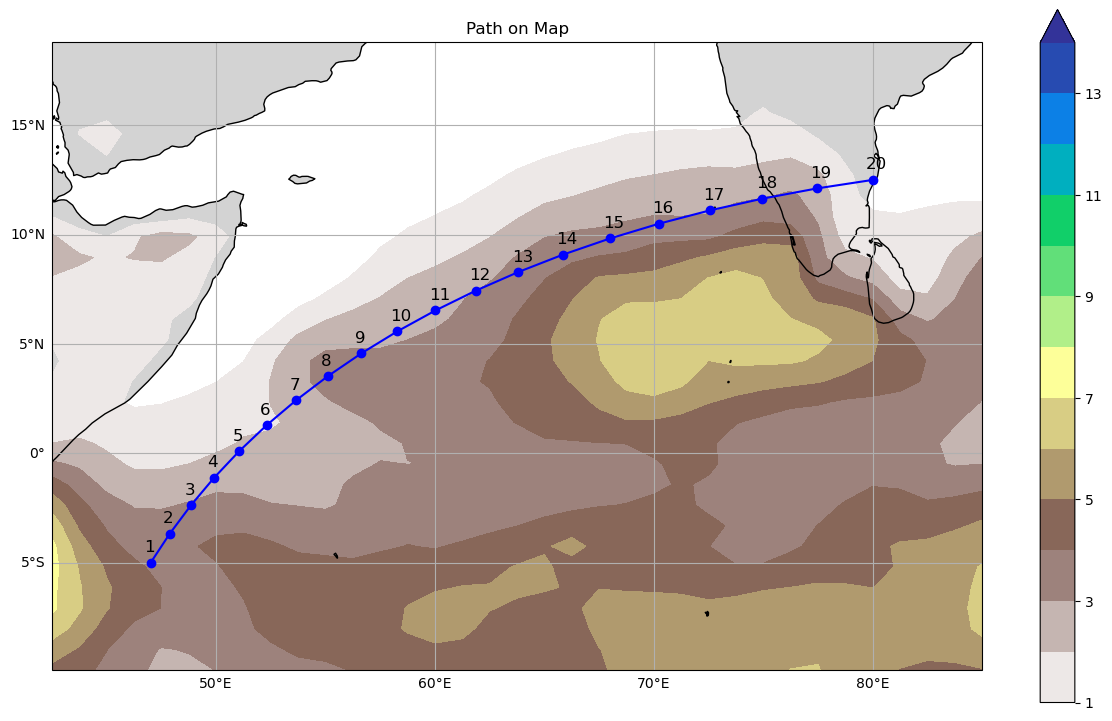

In [4]:
lon_points = [] ; lat_points = []

# Print or plot points
for lat, lon in arc:
    lat_points.append(lat.tolist())
    lon_points.append(lon.tolist())
    print(f"{lat:.4f}, {lon:.4f}")
    
myplot.plot_latlon_path(ds_in,var_cont,vscale_cont,lat_points, lon_points)

[-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]


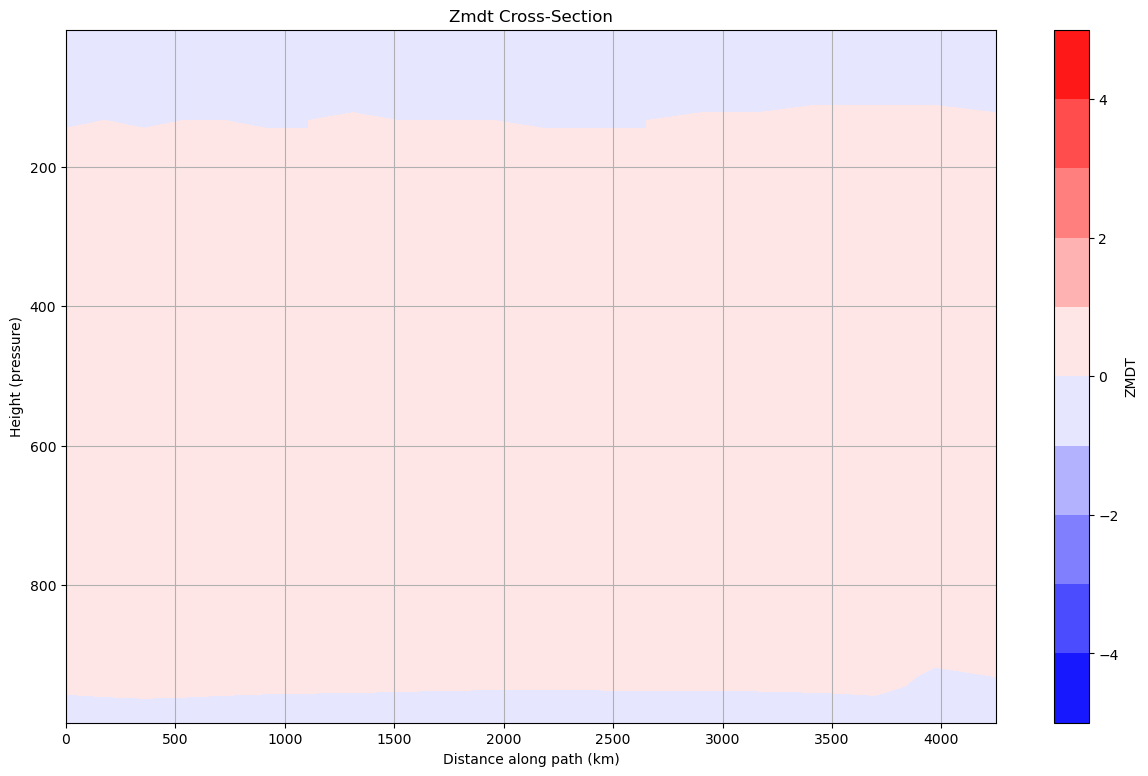

In [5]:
# Plot value of the 2D field along the specifed track

myplot.plot_cross_section(ds_in, var_c1d,var_c2d, lat_points, lon_points)